<div style="text-align: center;">

# Social Network Analysis (CS342) | Assignment 5

## **Eigenvector Centrality and PageRank Algorithm**

---

**Student Name:** *Naishadh Rana*

**Roll No:** U23CS014

---

</div>


**Part I - SVNIT web graph**
- Crawl SVNIT website and build a directed graph from links
- Visualize the web graph
- Print nodes, edges, in/out degree distribution, avg in/out degree
- Compute eigenvector centrality

**Part II - PageRank**
- Implement simple PageRank
- Run it on Karate Club graph
- Analyze: highest/lowest PageRank, self-loops, and rank vector


**Required Libraries:** `networkx`, `matplotlib`, `requests`, `beautifulsoup4`

In [37]:
import math
import time
from collections import deque, Counter
from urllib.parse import urljoin, urlparse, urldefrag

import requests
from bs4 import BeautifulSoup
import networkx as nx
import matplotlib.pyplot as plt

print("Imported")


Imported


## Part I — Web Graph of SVNIT

Crawling svnit.ac.in (directed):
- Node = webpage URL
- Edge = hyperlink from one page to another

**What I'm computing:**
- Nodes, edges, in/out degree distributions
- Eigenvector centrality

### Formulas

For directed graph with $N$ nodes, $M$ edges:

$$\bar{k}_{in} = \bar{k}_{out} = \frac{M}{N}$$

Where:
- $\bar{k}_{in}$ = average in-degree
- $\bar{k}_{out}$ = average out-degree

**Eigenvector Centrality:** 

$$x_v = \frac{1}{\lambda} \sum_{u} A_{uv} x_u$$

Where:
- $\lambda$ = largest eigenvalue of $A$
- $A_{uv}$ = adjacency matrix entry (1 if u links to v, else 0)

Basically nodes connected to important nodes become important themselves.


In [38]:
# helper functions for crawling

def normalize_url(url, base="https://www.svnit.ac.in/"):
    if not url:
        return None
    url = urljoin(base, url)
    url, _ = urldefrag(url)
    return url

def is_same_domain(url, domain="svnit.ac.in"):
    try:
        return urlparse(url).netloc.lower().endswith(domain)
    except:
        return False

def is_html_like(url):
    # skiping pdfs, images, docs etc
    skip = (".pdf", ".jpg", ".jpeg", ".png", ".gif", ".svg", ".doc", ".docx",
            ".xls", ".xlsx", ".ppt", ".pptx", ".zip", ".rar", ".7z")
    path = urlparse(url).path.lower()
    return not any(path.endswith(ext) for ext in skip)

def extract_links(html, base_url):
    soup = BeautifulSoup(html, "html.parser")
    links = []
    for a in soup.find_all("a", href=True):
        norm = normalize_url(a.get("href"), base=base_url)
        if norm:
            links.append(norm)
    return links


In [39]:
# crawl svnit website using BFS

seed_url = "https://www.svnit.ac.in/"
max_pages = 50
max_depth = 2
request_timeout = 10
sleep_sec = 0.4  # reducing speed to avoid DDoS-like behavior

G = nx.DiGraph()
visited = set()
q = deque([(seed_url, 0)])

while q and len(visited) < max_pages:
    url, depth = q.popleft()
    if url in visited or depth > max_depth:
        continue

    G.add_node(url)

    try:
        resp = requests.get(url, timeout=request_timeout, headers={"User-Agent": "SNA-Lab5"})
        if resp.status_code != 200:
            visited.add(url)
            continue
        html = resp.text
    except Exception as e:
        print(f"Failed: {url}")
        visited.add(url)
        continue

    visited.add(url)
    links = extract_links(html, url)

    for link in links:
        if is_same_domain(link) and is_html_like(link):
            G.add_edge(url, link)
            if link not in visited and depth + 1 <= max_depth:
                q.append((link, depth + 1))

    time.sleep(sleep_sec)

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())


Nodes: 435
Edges: 3349


In [50]:
# basic stats
n = G.number_of_nodes()
m = G.number_of_edges()

indeg = dict(G.in_degree())
outdeg = dict(G.out_degree())

avg_in = sum(indeg.values()) / n if n else 0
avg_out = sum(outdeg.values()) / n if n else 0

print(f"Nodes: {n}")
print(f"Edges: {m}")
print("=" * 10)
print(f"Minimum in-degree: {min(indeg.values())}")
print(f"Maximum in-degree: {max(indeg.values())}")
print(f"Avg in-degree: {avg_in:.3f}")
print("=" * 10)
print(f"Minimum out-degree: {min(outdeg.values())}")
print(f"Maximum out-degree: {max(outdeg.values())}")
print(f"Avg out-degree: {avg_out:.3f}")

Nodes: 435
Edges: 3349
Minimum in-degree: 1
Maximum in-degree: 49
Avg in-degree: 7.699
Minimum out-degree: 0
Maximum out-degree: 112
Avg out-degree: 7.699


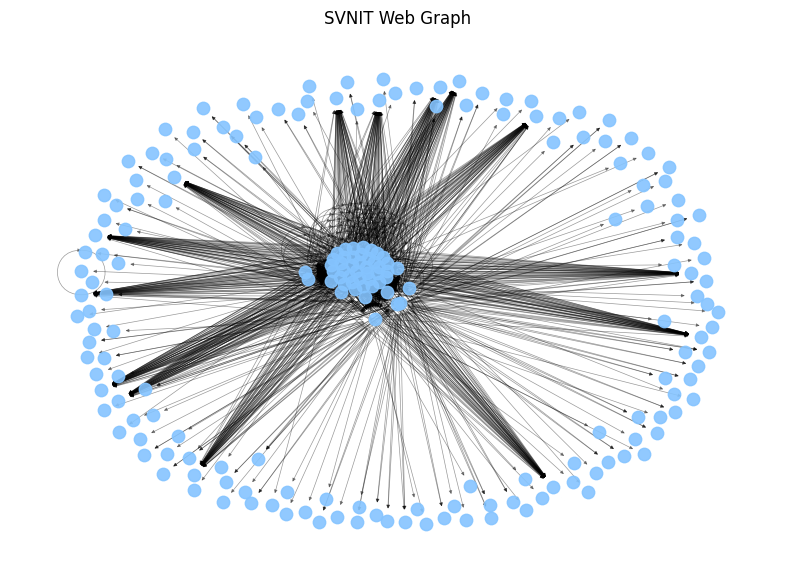

In [41]:
# visualize
plt.figure(figsize=(10, 7))

if n <= 200:
    H = G
else:
    H = G.subgraph(list(G.nodes())[:200]).copy()

pos = nx.spring_layout(H, seed=42, k=0.6)
nx.draw_networkx_nodes(H, pos, node_size=80, node_color="#85C4FFD7", alpha=0.9)
nx.draw_networkx_edges(H, pos, width=0.5, alpha=0.4, arrows=True, arrowsize=5)
plt.title("SVNIT Web Graph")
plt.axis("off")
plt.show()


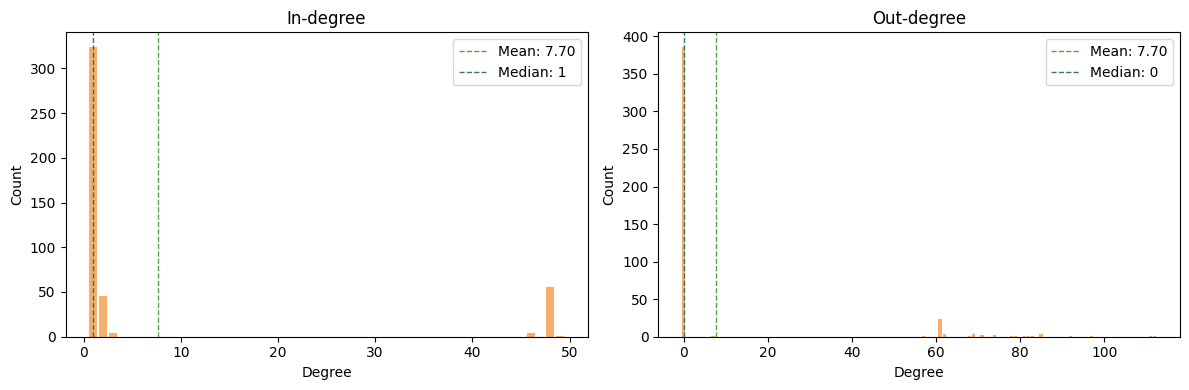

In [56]:
# degree distributions
in_counts = Counter(indeg.values())
out_counts = Counter(outdeg.values())

in_vals = list(indeg.values())
out_vals = list(outdeg.values())

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.bar(in_counts.keys(), in_counts.values(), color="#F28E2B", alpha=0.7)
plt.axvline(sum(in_vals)/len(in_vals), color="#4AA942FF", linestyle='--', linewidth=1, label=f'Mean: {sum(in_vals)/len(in_vals):.2f}')
plt.axvline(sorted(in_vals)[len(in_vals)//2], color="#2A6C6DEF", linestyle='--', linewidth=1, label=f'Median: {sorted(in_vals)[len(in_vals)//2]}')
plt.title("In-degree")
plt.xlabel("Degree")
plt.ylabel("Count")
plt.legend()

plt.subplot(1, 2, 2)
plt.bar(out_counts.keys(), out_counts.values(), color="#F28E2B", alpha=0.7)
plt.axvline(sum(out_vals)/len(out_vals), color="#4AA942FF", linestyle='--', linewidth=1, label=f'Mean: {sum(out_vals)/len(out_vals):.2f}')
plt.axvline(sorted(out_vals)[len(out_vals)//2], color="#2A6C6DEF", linestyle='--', linewidth=1, label=f'Median: {sorted(out_vals)[len(out_vals)//2]}')
plt.title("Out-degree")
plt.xlabel("Degree")
plt.ylabel("Count")
plt.legend()

plt.tight_layout()
plt.show()


In [43]:
# eigenvector centrality
if n > 0:
    try:
        eig = nx.eigenvector_centrality(G, max_iter=1000)
    except:
        eig = nx.eigenvector_centrality_numpy(G)

    top10 = sorted(eig.items(), key=lambda x: x[1], reverse=True)[:10]
    print("Top 10 by eigenvector centrality:")
    for url, score in top10:
        print(f"{score:.5f}  {url}")
else:
    eig = {}
    print("Empty graph")


Top 10 by eigenvector centrality:
0.13094  https://help.ccc.svnit.ac.in
0.12816  https://www.svnit.ac.in/index.php
0.12816  https://www.svnit.ac.in/web/about-us.php
0.12816  https://www.svnit.ac.in/web/mission-vision.php
0.12816  https://www.svnit.ac.in/web/annual-report.php
0.12816  https://www.svnit.ac.in/web/annual-account-report.php
0.12816  https://www.svnit.ac.in/web/nirf.php
0.12816  https://www.svnit.ac.in/web/bog.php
0.12816  https://www.svnit.ac.in/web/senate_members.php
0.12816  https://www.svnit.ac.in/web/finance_committee.php


### Part I - SVNIT Web Graph
- Nodes: 435
- Edges: 3349
- Avg in/out degree: ~7.7
- Top pages by eigenvector centrality are the main index and about pages (makes sense, everything links to them)

---

## Part II — PageRank from Scratch

### Formula Used:

$$PR(v) = \frac{1-d}{N} + d \sum_{u \rightarrow v} \frac{PR(u)}{out(u)} + d \cdot \frac{S}{N}$$

Where:
- $d$ = damping factor (usually 0.85)
- $S$ = sum of PageRank of sink nodes (no outgoing links)
- $N$ = total number of nodes
- $u$ = nodes linking to $v$


### Algorithm
1. Start everyone with $1/N$
2. Keep updating using the formula
3. Stop when values barely change


In [44]:
def prank(G, d=0.85, max_iter=100, tol=1e-6):
    if G.number_of_nodes() == 0:
        return {}

    nodes = list(G.nodes())
    n = len(nodes)
    idx = {node: i for i, node in enumerate(nodes)}
    
    pr = [1.0 / n] * n
    out = {node: G.out_degree(node) for node in nodes}

    for _ in range(max_iter):
        new_pr = [0.0] * n
        
        # handle sink nodes (no outgoing links)
        sink = sum(pr[idx[node]] for node in nodes if out[node] == 0)

        for u in nodes:
            if out[u] == 0:
                continue
            share = pr[idx[u]] / out[u]
            for v in G.successors(u):
                new_pr[idx[v]] += share

        # apply damping
        for i in range(n):
            new_pr[i] = (1 - d) / n + d * (new_pr[i] + sink / n)

        # check if converged
        diff = sum(abs(new_pr[i] - pr[i]) for i in range(n))
        pr = new_pr
        if diff < tol:
            break

    return {node: pr[idx[node]] for node in nodes}


In [45]:
# test on karate club
K = nx.karate_club_graph().to_directed()  # undirected -> directed

pr = prank(K, d=0.85, max_iter=200, tol=1e-8)

best = max(pr, key=pr.get)
worst = min(pr, key=pr.get)

print(f"Highest: node {best} ({pr[best]:.6f})")
print(f"Lowest: node {worst} ({pr[worst]:.6f})")
print(f"Self-loops: {'Yes' if nx.selfloop_edges(K) else 'No'}")

print("\nAll nodes (sorted by PageRank):")
for node, score in sorted(pr.items(), key=lambda x: x[1], reverse=True):
    print(f"  {node:>2}: {score:.6f}")


Highest: node 33 (0.100919)
Lowest: node 11 (0.009565)
Self-loops: Yes

All nodes (sorted by PageRank):
  33: 0.100919
   0: 0.096997
  32: 0.071693
   2: 0.057079
   1: 0.052877
  31: 0.037158
   3: 0.035860
  23: 0.031523
   8: 0.029766
  13: 0.029536
   5: 0.029111
   6: 0.029111
  29: 0.026289
  27: 0.025640
  30: 0.024590
   7: 0.024490
   4: 0.021978
  10: 0.021978
  24: 0.021076
  25: 0.021006
  19: 0.019605
  28: 0.019573
  16: 0.016784
  26: 0.015044
  12: 0.014645
  17: 0.014559
  21: 0.014559
  14: 0.014536
  15: 0.014536
  18: 0.014536
  20: 0.014536
  22: 0.014536
   9: 0.014309
  11: 0.009565


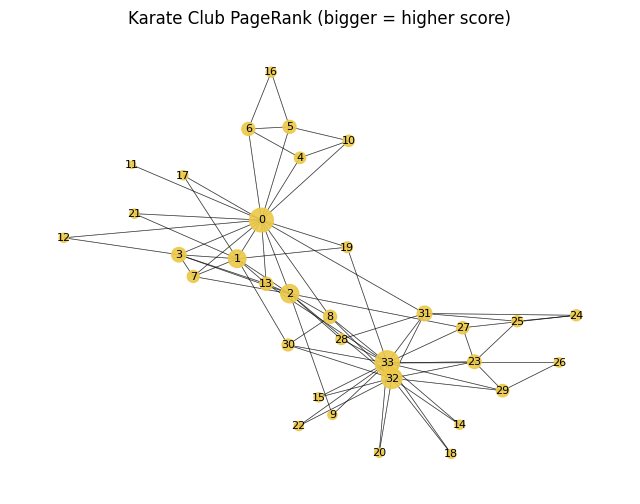

In [46]:
# visualize pagerank on karate club
plt.figure(figsize=(8, 6))

sizes = [3000 * pr[node] for node in K.nodes()]
pos = nx.spring_layout(K, seed=42)

nx.draw_networkx_nodes(K, pos, node_size=sizes, node_color="#EDC948", alpha=0.9)
nx.draw_networkx_edges(K, pos, width=0.5, alpha=0.5, arrows=False)
nx.draw_networkx_labels(K, pos, font_size=8)

plt.title("Karate Club PageRank (bigger = higher score)")
plt.axis("off")
plt.show()


### Part II - Karate Club PageRank
- Node 33 has highest PageRank (0.1009) - this is the club president
- Node 11 has lowest (0.0096) - peripheral member
- Top 5: 33, 0, 32, 2, 1
- No self-loops

The high-PageRank nodes are the "leaders" of the club . They have many connections and are connected to other important members.